In [1]:
import json
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.spatial import ConvexHull

# read kissat file

In [3]:
# code size
n = 5

In [4]:
# dictionnary of mapping between z3 and kissat variables
def parse_dimacs_mapping(cnf_file):
    mapping = {}
    
    with open(cnf_file, 'r') as file:
        for line in file:
            if line.startswith('c '): 
                parts = line.split()
                if len(parts) == 3 and parts[0] == 'c' and parts[1].isdigit():
                    kissat_var = int(parts[1])
                    original_var = parts[2]
                    mapping[kissat_var] = original_var
    
    return mapping

In [5]:
# dictionnary z3 variable -> SAT result
def read_kissat_output(kissat_output_file, mapping):
    result = {}
    
    with open(kissat_output_file, 'r') as file:
        for line in file:
            if line.startswith('v '):
                parts = line.split()
                for part in parts[1:]:
                    var = int(part)
                    if var > 0:  # Positive value -> variable True
                        assignment = True
                    else:  # Negative value -> variable False
                        var = -var
                        assignment = False
                    
                    # Retrieve the original variable name using the mapping
                    original_var = mapping.get(var)
                    if original_var:
                        result[original_var] = assignment
    
    return result

In [6]:
kissat_result = read_kissat_output(f"./kissat.txt",
                                   parse_dimacs_mapping("./Code_search.cnf"))

## retrieve variables

In [7]:
# connection between qubits
Connection_Result = np.zeros((n,n,8),dtype = int)
for i in range(n):
    for j in range(n):
        for k in range(8):
            Connection_Result[i,j,k] = kissat_result[f"c_{i}{j}{k}"]

In [9]:
# XL rotation on each qubit
Rotation_Result = np.zeros((n,n,5),dtype = int)
for i in range(n):
    for j in range(n):
        for k in range(5):
            Rotation_Result[i,j,k] = kissat_result[f"r_{i}{j}{k}"]

# Plot connection graph

## graph

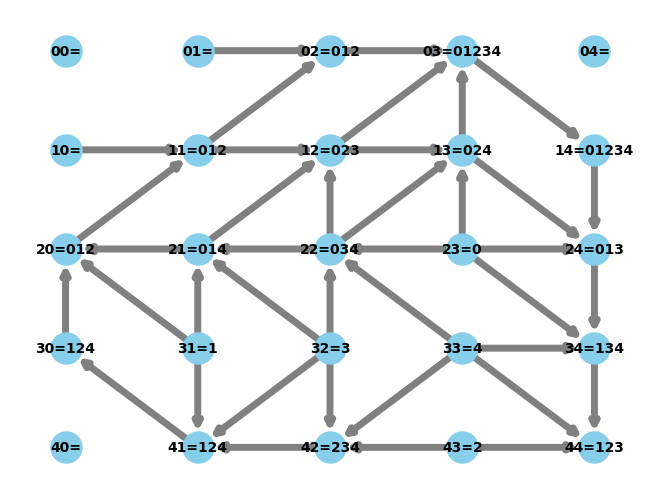

In [10]:
G = nx.DiGraph()

# qubit name: position and associated XL rotation
name = {}
for i in range(n):
    for j in range(n):
        name[(i,j)] = f'{i}{j}'+'='+''.join(np.where(Rotation_Result[i,j])[0].astype(str))

# qubit position
pos = {}
for i in range(n):
    for j in range(n):
        G.add_node(name[(i,j)])
        pos[name[(i,j)]] = (j,n-i)
        
# connections between qubits
for i in range(n):
    for j in range(n):
        if Connection_Result[i,j][0] == 1:
            G.add_edge(name[(i,j)],name[(i-1,j)])
        if Connection_Result[i,j][1] == 1:
            G.add_edge(name[(i,j)],name[(i-1,j+1)])
        if Connection_Result[i,j][2] == 1:
            G.add_edge(name[(i,j)],name[(i,j+1)])
        if Connection_Result[i,j][3] == 1:
            G.add_edge(name[(i,j)],name[(i+1,j+1)])
        if Connection_Result[i,j][4] == 1:
            G.add_edge(name[(i,j)],name[(i+1,j)])
        if Connection_Result[i,j][5] == 1:
            G.add_edge(name[(i,j)],name[(i+1,j-1)])
        if Connection_Result[i,j][6] == 1:
            G.add_edge(name[(i,j)],name[(i,j-1)])
        if Connection_Result[i,j][7] == 1:
            G.add_edge(name[(i,j)],name[(i-1,j-1)])
            
# draw graph
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=500, 
        font_size=10, font_weight='bold', edge_color='gray', width=5)        

## reduced graph

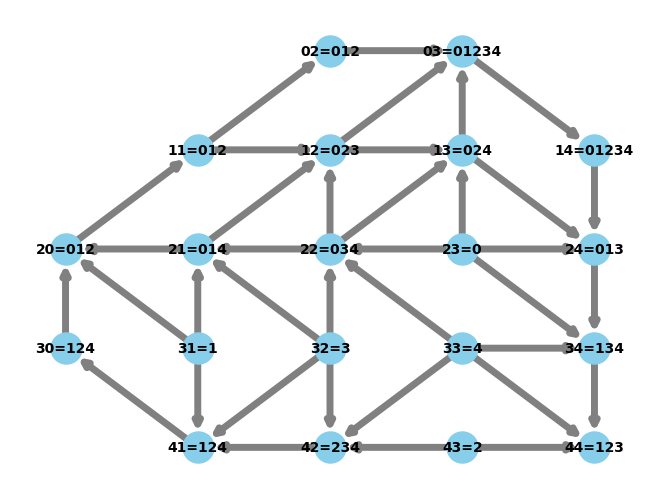

In [11]:
# remove nodes with no rotation
nodes_to_remove = [node for node in G.nodes if node.endswith('=')]
G.remove_nodes_from(nodes_to_remove)

# draw reduced graph
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=500, 
        font_size=10, font_weight='bold', edge_color='gray', width=5)    

# Plot stabilizers

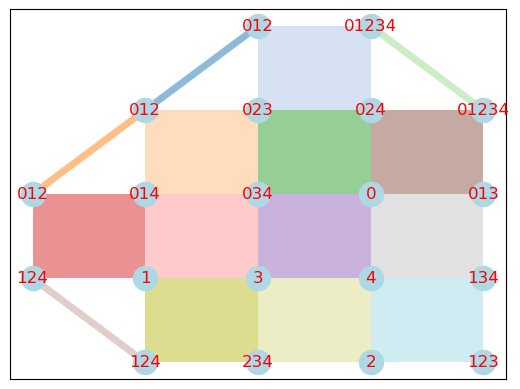

In [13]:
# plot stabilizers associated to graph
def plot_stabilizers(G, pos):

    fig, ax = plt.subplots()

    # Draw only the nodes (no edges)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=300, node_color='lightblue')
    
    # draw XL rotation associated to qubit
    for i in range(n):
        for j in range(n):
            plt.text(i, j+1, ''.join(np.where(Rotation_Result[n-j-1,i])[0].astype(str)), 
                     fontsize=12, color='red', ha='center', va='center')
    
    # color cycle for stabilizers
    color_cycle = plt.cm.tab20.colors

    # Draw stabilizer between a qubit and its predecessor
    for i, node in enumerate(G.nodes()):
        
        # qubit connected to current qubit
        predecessors = list(G.predecessors(node))
        # position of the qubits within stabilizer
        points = [pos[node]] + [pos[predecessor] for predecessor in predecessors]
        
        color = color_cycle[i % len(color_cycle)]
        
        # take convex hull if weight-4 stabilizer
        if len(points) >= 4:
            points_array = np.array(points)
            hull = ConvexHull(np.array(points))
            points = points_array[hull.vertices]
        
        # plot stabilizer
        polygon = patches.Polygon(points, closed=True, color=color, alpha=0.5, linewidth=0)
        
        # If weight-2 stabilizer, increase width
        if len(points) == 2:
            polygon.set_linewidth(5)  
        
        # Add the stabilizer to the plot
        ax.add_patch(polygon)

    plt.show()

# plot stabilizers
plot_stabilizers(G, pos)

# Save code

In [14]:
# relabel qubits with integer
node_mapping = {old_name: new_name for new_name, old_name in enumerate(G.nodes)}
G = nx.relabel_nodes(G, node_mapping)

node_mapping

{'02=012': 0,
 '03=01234': 1,
 '11=012': 2,
 '12=023': 3,
 '13=024': 4,
 '14=01234': 5,
 '20=012': 6,
 '21=014': 7,
 '22=034': 8,
 '23=0': 9,
 '24=013': 10,
 '30=124': 11,
 '31=1': 12,
 '32=3': 13,
 '33=4': 14,
 '34=134': 15,
 '41=124': 16,
 '42=234': 17,
 '43=2': 18,
 '44=123': 19}

In [15]:
# information qubits where X physical = X logical
targeted_info_qubits = ['0','1','2','3','4']

info_qubits = []
for key in node_mapping:
    rotation_string = key.split("=", 1)[1]
    if rotation_string in targeted_info_qubits:
        targeted_info_qubits.remove(rotation_string)
        info_qubits.append(node_mapping[key])
        
info_qubits

[9, 12, 13, 14, 18]

In [16]:
# qubit that will host the output magic state
out_qubits = []

for key in node_mapping:
    rotation_string = key.split("=", 1)[1]
    if rotation_string == '2':
        out_qubits.append(node_mapping[key])
        
out_qubits

[18]

In [17]:
# 15 XL rotation
targeted_rotations = ['0', '1', '3', '4', '123', '012', '013', '023', '034', '014', '024', '01234', '234', '134', '124']

rotations = []

for index,targeted_rotations_string in enumerate(targeted_rotations):
    for key in node_mapping:
        rotation_string = key.split("=", 1)[1]
        if rotation_string ==  targeted_rotations_string:
            rotations.append(node_mapping[key])
            break
    
rotations

[9, 12, 13, 14, 19, 0, 10, 3, 8, 7, 4, 1, 17, 15, 11]

In [18]:
# stabilizers

stabilizers = []

for node in G.nodes:
    predecessors = list(G.predecessors(node))
    if len(predecessors)>0:
        stab = [node] + predecessors
        stabilizers.append(stab)
        
stabilizers.sort(key=lambda sublist: min(sublist))

stabilizers

[[0, 2],
 [1, 0, 3, 4],
 [5, 1],
 [2, 6],
 [3, 2, 7, 8],
 [4, 3, 8, 9],
 [10, 4, 5, 9],
 [6, 7, 11, 12],
 [7, 8, 12, 13],
 [8, 9, 13, 14],
 [15, 9, 10, 14],
 [11, 16],
 [16, 12, 13, 17],
 [17, 13, 14, 18],
 [19, 14, 15, 18]]

In [20]:
# save dictionary

dict_save = {}
dict_save['stabilzers'] = stabilizers
dict_save['rotations'] = rotations
dict_save['info_qubits'] = info_qubits
dict_save['out_qubits'] = out_qubits

with open('UnfoldedCode.json', 'w') as json_file:
    json.dump(dict_save, json_file)